In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

I0000 00:00:1780639565.106459   10906 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780639585.458541   10906 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780639595.194747   10906 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [3]:
crop = pd.read_csv("/workspaces/farmer_crop_climate_mismatch_system/datasets/Crop_recommendation.csv")

X = crop.drop("label", axis=1)
y = crop["label"]

In [4]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Number of Classes:", len(label_encoder.classes_))

Number of Classes: 22


In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [7]:
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [8]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(7,)))

model.add(Dense(32, activation='relu'))

model.add(Dense(22, activation='softmax'))

/workspaces/farmer_crop_climate_mismatch_system/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1780639707.997572   10906 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [15]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(7,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(22, activation='softmax')
])

In [16]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
print("Starting training...")

history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=100,
    batch_size=32
)

Starting training...
Epoch 1/100


44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2642 - loss: 2.7743 - val_accuracy: 0.3778 - val_loss: 2.3755
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5732 - loss: 1.7891 - val_accuracy: 0.5767 - val_loss: 1.3261
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7592 - loss: 0.8856 - val_accuracy: 0.8324 - val_loss: 0.6600
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8864 - loss: 0.4646 - val_accuracy: 0.8466 - val_loss: 0.4366
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9190 - loss: 0.3207 - val_accuracy: 0.9261 - val_loss: 0.3023
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9432 - loss: 0.2362 - val_accuracy: 0.9290 - val_loss: 0.2385
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9467 - loss: 0.1914 - val_accuracy: 0.9545 - val_loss: 0.1929
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9659 - loss: 0.1469 - val_accuracy: 0.9432 - val_loss: 0.

In [18]:
loss, accuracy = model.evaluate(X_test, y_test_cat)
print("Accuracy:", accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9727 - loss: 0.1069  
Accuracy: 0.9727272987365723


In [19]:
loss, accuracy = model.evaluate(X_test, y_test_cat)

print("Neural Network Accuracy:", round(accuracy * 100, 2), "%")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9727 - loss: 0.1069 
Neural Network Accuracy: 97.27 %


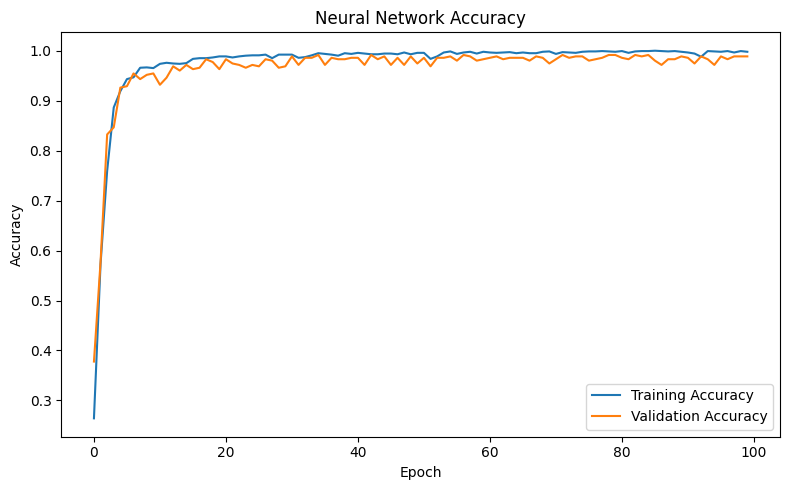

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Neural Network Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.tight_layout()

plt.savefig("../screenshots/neural_network_training.png")

plt.show()

In [22]:
import pandas as pd

rainfall = pd.read_csv("/workspaces/farmer_crop_climate_mismatch_system/datasets/district wise rainfall normal.csv")

In [23]:
print(rainfall["STATE_UT_NAME"].nunique())
print(rainfall["DISTRICT"].nunique())

print(rainfall[["STATE_UT_NAME","DISTRICT","ANNUAL"]].head())

35
637
                 STATE_UT_NAME       DISTRICT  ANNUAL
0  ANDAMAN And NICOBAR ISLANDS        NICOBAR  2805.2
1  ANDAMAN And NICOBAR ISLANDS  SOUTH ANDAMAN  3015.7
2  ANDAMAN And NICOBAR ISLANDS  N & M ANDAMAN  2913.3
3            ARUNACHAL PRADESH          LOHIT  3043.8
4            ARUNACHAL PRADESH     EAST SIANG  4034.7
